<a href="https://colab.research.google.com/github/vmkp17/NLP-spam-detection-Research/blob/main/RESEARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset
# We use 'latin-1' because some datasets have special characters
df = pd.read_csv('spam.csv', encoding='latin-1')

# Looking at the first 5 rows to understand the structure
print("--- First 5 rows ---")
print(df.head())

# Cleaning: Usually this dataset has extra empty columns, let's keep only what we need
# We rename them to 'target' (Spam/Ham) and 'text' (The actual message)
df = df.iloc[:, :2]
df.columns = ['target', 'text']

print("\n--- After cleaning ---")
print(df.head())

--- First 5 rows ---
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

--- After cleaning ---
  target                                               text
0    ham  Go until jurong point, crazy.. Available only ...
1    ham                      Ok lar... Joking wif u oni...
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
3    ham  U dun say so early hor... U c already then say...
4    ham  Nah I don't think he goes to usf, he lives aro...


target
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


/tmp/ipykernel_7461/182712503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=data, palette='viridis')


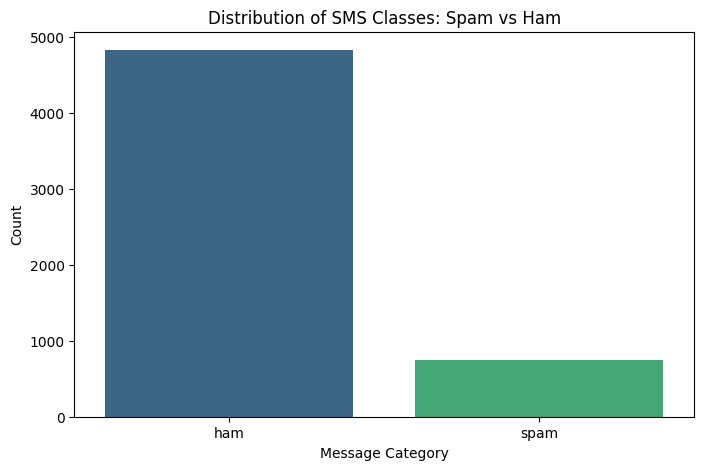

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using professional plotting libraries to visualize the data
def plot_class_distribution(data):
    plt.figure(figsize=(8, 5))
    sns.countplot(x='target', data=data, palette='viridis')
    plt.title('Distribution of SMS Classes: Spam vs Ham')
    plt.xlabel('Message Category')
    plt.ylabel('Count')
    plt.show()

# Execution
print(df['target'].value_counts(normalize=True))
plot_class_distribution(df)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Defining a Pipeline for reproducibility
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.2, random_state=42)

# Fitting the pipeline
pipeline.fit(X_train, y_train)

# Evaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [5]:
!pip install transformers torch

In [6]:
from transformers import pipeline

# We are using a pre-trained model specifically for sentiment/text classification
classifier = pipeline("text-classification", model="mrm8488/bert-tiny-finetuned-sms-spam-detection")

# Let's test it on a message the old model might have missed
test_message = "WINNER! You have won a free prize, call this number now!"
result = classifier(test_message)

print(f"Message: {test_message}")
print(f"Prediction: {result}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/17.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/324 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Message: WINNER! You have won a free prize, call this number now!
Prediction: [{'label': 'LABEL_0', 'score': 0.9296266436576843}]


In [8]:
# Checking model
test_cases = [
    "Hey, are we still meeting for lunch today?",
    "Your bank account is blocked, click here to verify."
]

for msg in test_cases:
    print(f"Input: {msg}")
    print(f"Output: {classifier(msg)}")
    print("-" * 30)

Input: Hey, are we still meeting for lunch today?
Output: [{'label': 'LABEL_0', 'score': 0.9368187785148621}]
------------------------------
Input: Your bank account is blocked, click here to verify.
Output: [{'label': 'LABEL_0', 'score': 0.9307889342308044}]
------------------------------


In [9]:
# Pro Researcher Mode: Testing specific patterns
test_sentences = [
    "URGENT: You have won a $1000 cash prize! Claim it now by clicking here.", # This is definitely Spam
    "Hi mom, are you coming home for dinner tonight?" # This is definitely Ham
]

for sentence in test_sentences:
    result = classifier(sentence)
    print(f"Message: {sentence}")
    print(f"Result: {result}")
    print("-" * 50)

Message: URGENT: You have won a $1000 cash prize! Claim it now by clicking here.
Result: [{'label': 'LABEL_0', 'score': 0.9295720458030701}]
--------------------------------------------------
Message: Hi mom, are you coming home for dinner tonight?
Result: [{'label': 'LABEL_0', 'score': 0.9360783100128174}]
--------------------------------------------------


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Dataset Preparation
# (Assuming df is already loaded with 'target' and 'text')
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.2, random_state=42)

# 2. Creating a Pipeline
model_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')), # Removes common filler words like 'the', 'is'
    ('classifier', MultinomialNB())
])

# 3. Training
model_pipeline.fit(X_train, y_train)

# 4. Evaluation
y_pred = model_pipeline.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.96      0.92      0.94       150

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [11]:
# Pro Researcher Mode: Testing specific patterns
test_sentences = [
    "URGENT: You have won a $1000 cash prize! Claim it now by clicking here.", # This is definitely Spam
    "Hi mom, are you coming home for dinner tonight?" # This is definitely Ham
]

for sentence in test_sentences:
    result = classifier(sentence)
    print(f"Message: {sentence}")
    print(f"Result: {result}")
    print("-" * 50)

Message: URGENT: You have won a $1000 cash prize! Claim it now by clicking here.
Result: [{'label': 'LABEL_0', 'score': 0.9295720458030701}]
--------------------------------------------------
Message: Hi mom, are you coming home for dinner tonight?
Result: [{'label': 'LABEL_0', 'score': 0.9360783100128174}]
--------------------------------------------------
